# Task 1 — Nasdaq Stock Price Prediction

**CS313 Deep Learning for Artificial Intelligence · Spring 2026**

This notebook covers:
- **Task 1.1** Multi-feature extension (Open, High, Low, Close, Adj Close, Volume)
- **Task 1.2** k-th day forecast
- **Task 1.3** k consecutive days forecast

Selected companies: `AAPL, AMZN, ASML, CSCO, FANG, JPM-PC, MSFT, ORLY, QCOM, VLY`

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import yfinance as yf

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
print(f"TF version: {tf.__version__}")


TF version: 2.20.0


In [2]:
# ── Configuration ────────────────────────────────────────────
TICKERS = ["AAPL", "AMZN", "ASML", "CSCO", "FANG",
           "JPM-PC", "MSFT", "ORLY", "QCOM", "VLY"]

# Features used as model inputs
FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
TARGET_COL   = 'Close'

WINDOW_SIZE   = 60   # 60-trading-day (~3 month) look-back window
K_DAY         = 7    # forecast the 7th day ahead (Task 1.2)
K_CONSEC      = 7    # forecast 7 consecutive days (Task 1.3)
MIN_ROWS      = 120  # filter companies with at least 120 data points
EPOCHS        = 50
BATCH_SIZE    = 64
LR            = 1e-3


## 1. Data Loading & EDA

In [10]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import yfinance as yf

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
print(f"TF version: {tf.__version__}")

# Download from Yahoo Finance (2010 – today)
raw_data = {}
for ticker in TICKERS:
    try:
        df = yf.download(ticker, start="2010-01-01", progress=False)
        df.columns = [c if isinstance(c, str) else c[0] for c in df.columns]  # flatten MultiIndex

        # Ensure 'Adj Close' column exists. If not, assume it's the same as 'Close'.
        if 'Adj Close' not in df.columns:
            if 'Close' in df.columns:
                df['Adj Close'] = df['Close']
            else:
                print(f"  {ticker:8s}  SKIPPED: 'Close' and 'Adj Close' columns are missing. Actual columns: {df.columns.tolist()}")
                continue # Skip this ticker if essential columns are missing

        df.dropna(inplace=True)
        if len(df) >= MIN_ROWS:
            raw_data[ticker] = df
            print(f"  {ticker:8s}  {len(df):5d} rows  "
                  f"{df.index[0].date()} → {df.index[-1].date()}")
        else:
            print(f"  {ticker:8s}  SKIPPED (only {len(df)} rows)")
    except Exception as e:
        print(f"  {ticker:8s}  ERROR: {e}")

print(f"\nLoaded {len(raw_data)} companies.")

TF version: 2.20.0
  AAPL       4112 rows  2010-01-04 → 2026-05-08
  AMZN       4112 rows  2010-01-04 → 2026-05-08
  ASML       4112 rows  2010-01-04 → 2026-05-08
  CSCO       4112 rows  2010-01-04 → 2026-05-08
  FANG       3411 rows  2012-10-12 → 2026-05-08
  JPM-PC     1836 rows  2019-01-18 → 2026-05-08
  MSFT       4112 rows  2010-01-04 → 2026-05-08
  ORLY       4112 rows  2010-01-04 → 2026-05-08
  QCOM       4112 rows  2010-01-04 → 2026-05-08
  VLY        4112 rows  2010-01-04 → 2026-05-08

Loaded 10 companies.


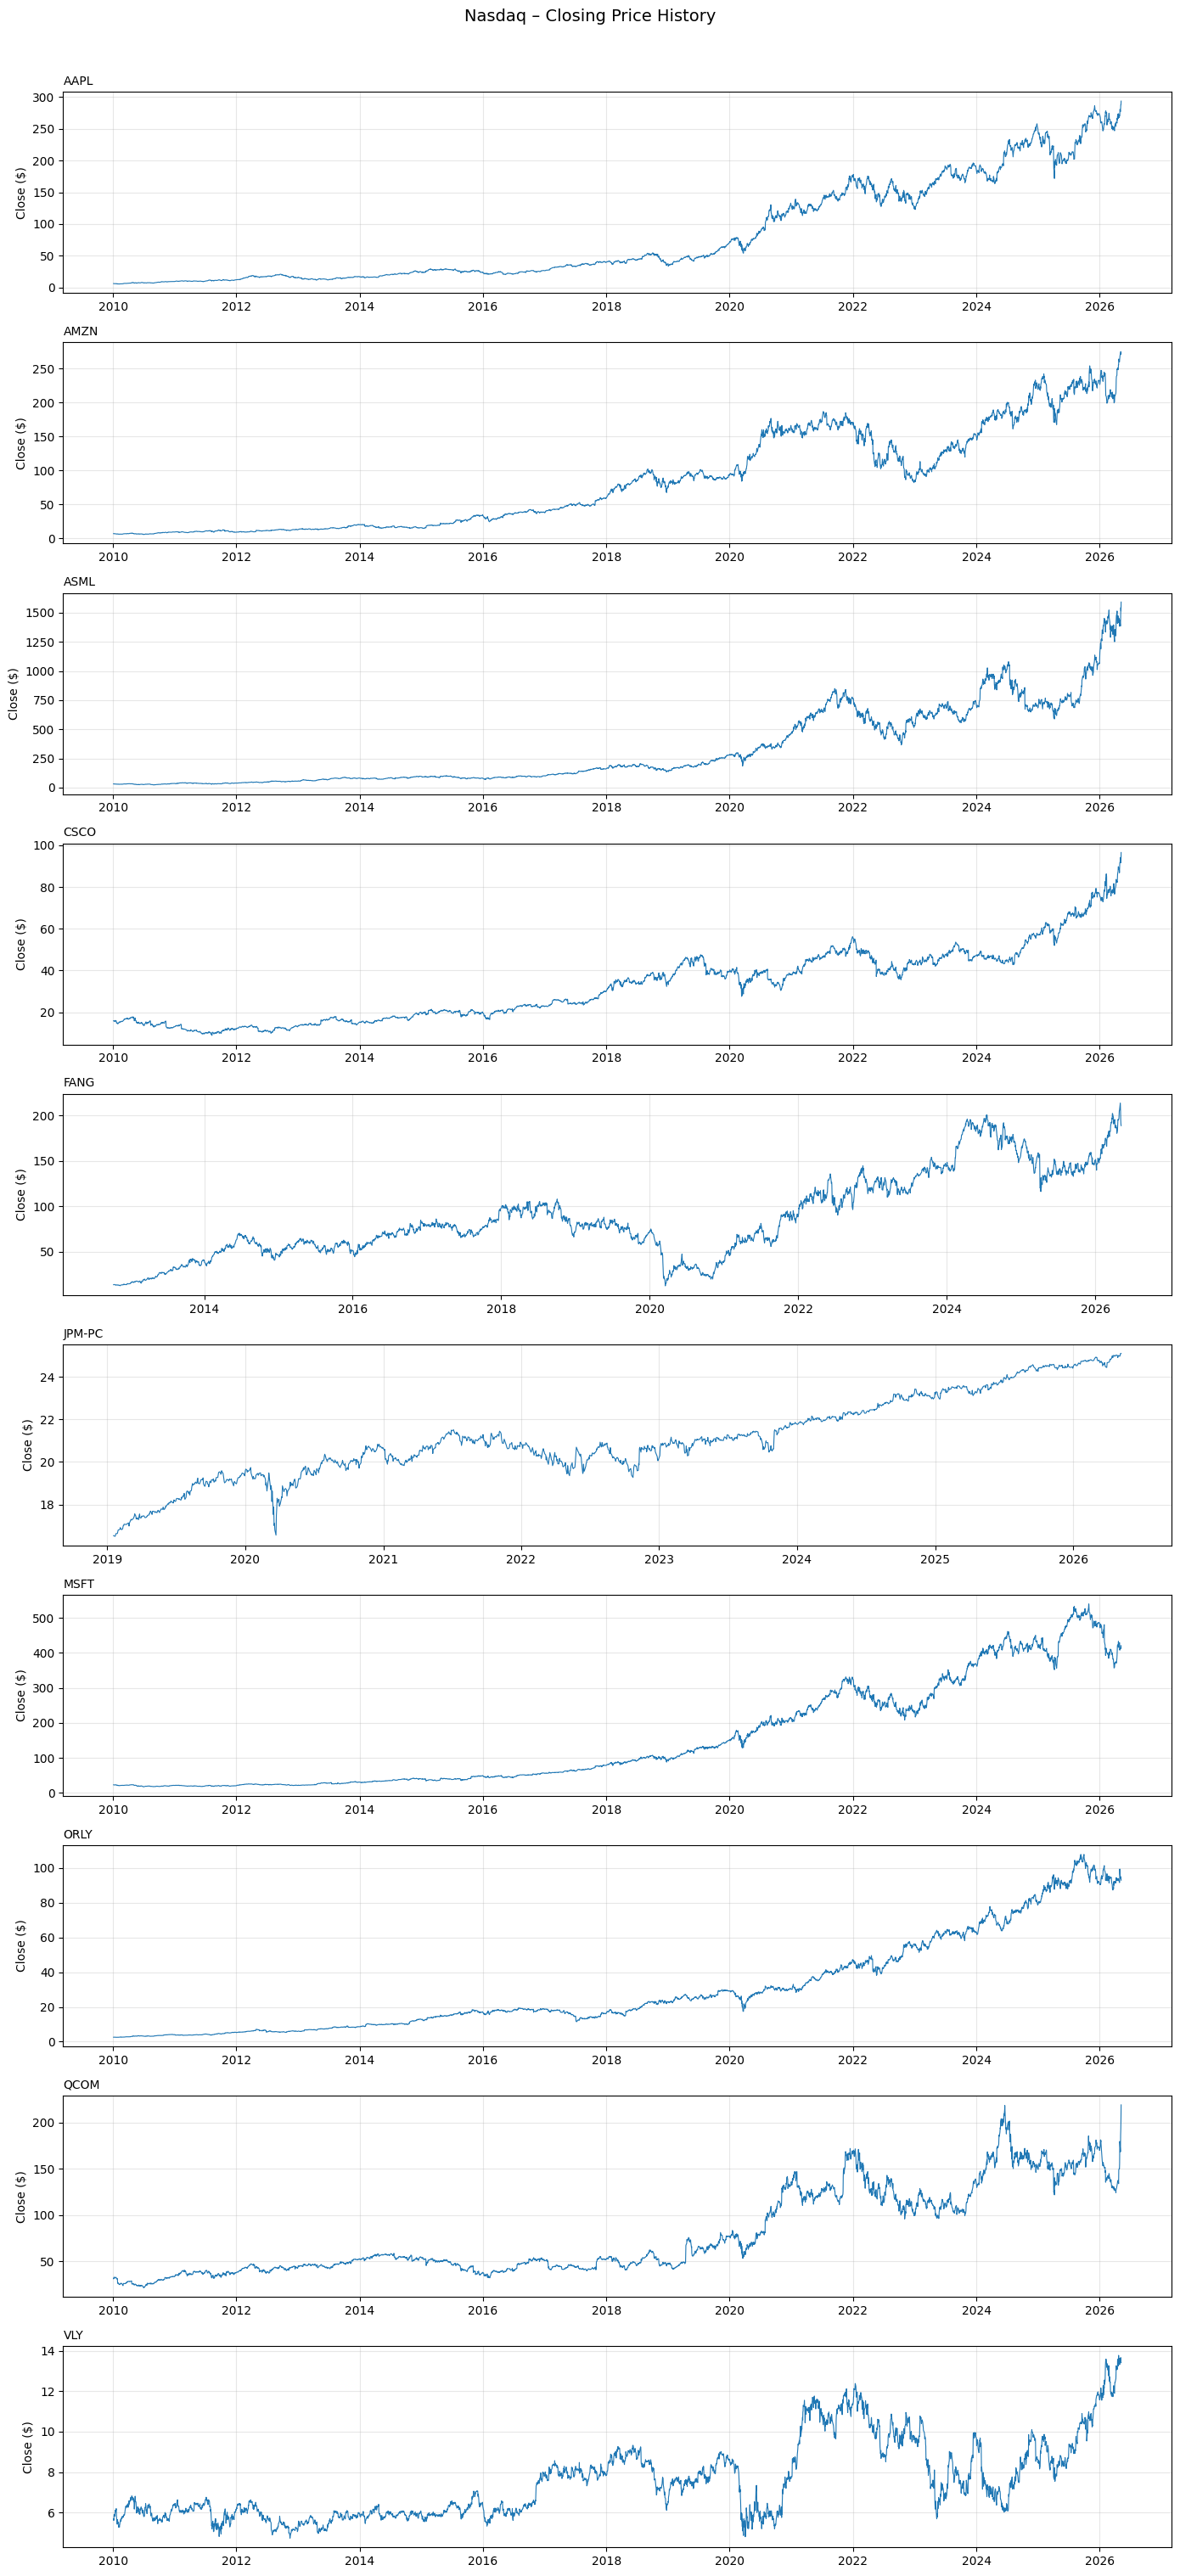

In [4]:
# Quick EDA: closing price overview
fig, axes = plt.subplots(len(raw_data), 1, figsize=(14, 3*len(raw_data)), sharex=False)
for ax, (ticker, df) in zip(axes, raw_data.items()):
    ax.plot(df.index, df['Close'], linewidth=0.8)
    ax.set_title(ticker, fontsize=10, loc='left')
    ax.set_ylabel('Close ($)')
    ax.grid(alpha=0.3)
plt.suptitle('Nasdaq – Closing Price History', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 2. Preprocessing Utilities

Key design decisions:
- **Window-based MinMax scaling**: each window is normalised independently so the model learns *relative* movements, not absolute price levels. This avoids look-ahead bias in normalisation.
- **Chronological split** (no shuffling): 60 % train → 20 % val → 20 % test.
- **EarlyStopping + ReduceLROnPlateau** to prevent overfitting.
- **Bidirectional LSTM** for richer sequential context, with L2 regularisation and Dropout.

In [11]:
def make_multi_feature_windows(df, window_size, feature_cols, target_col):
    """
    Build (X, y) arrays from a multi-feature DataFrame.
    X shape : (n_samples, window_size, n_features)
    y shape : (n_samples,)  — next-day target value (raw, un-normalised)
    """
    arr = df[feature_cols].values.astype(np.float32)
    tgt = df[target_col].values.astype(np.float32)

    X, y = [], []
    for i in range(len(arr) - window_size - 1):
        X.append(arr[i : i + window_size])
        y.append(tgt[i + window_size])          # next-day close

    return np.array(X), np.array(y)


def make_kth_day_windows(df, window_size, feature_cols, target_col, k):
    """
    Target is the price k days ahead of the window end.
    """
    arr = df[feature_cols].values.astype(np.float32)
    tgt = df[target_col].values.astype(np.float32)

    X, y = [], []
    for i in range(len(arr) - window_size - k):
        X.append(arr[i : i + window_size])
        y.append(tgt[i + window_size + k - 1])  # k-th day ahead

    return np.array(X), np.array(y)


def make_multi_output_windows(df, window_size, feature_cols, target_col, k):
    """
    Target is a vector of k consecutive prices after the window.
    y shape: (n_samples, k)
    """
    arr = df[feature_cols].values.astype(np.float32)
    tgt = df[target_col].values.astype(np.float32)

    X, y = [], []
    for i in range(len(arr) - window_size - k):
        X.append(arr[i : i + window_size])
        y.append(tgt[i + window_size : i + window_size + k])

    return np.array(X), np.array(y)


In [15]:
def chrono_split(X, y, val_ratio=0.2, test_ratio=0.2):
    """Strict chronological 60/20/20 split — no shuffle."""
    n = len(X)
    test_start = int(n * (1 - test_ratio))
    val_start  = int(test_start * (1 - val_ratio))

    X_train, y_train = X[:val_start],              y[:val_start]
    X_val,   y_val   = X[val_start:test_start],    y[val_start:test_start]
    X_test,  y_test  = X[test_start:],             y[test_start:]
    return X_train, y_train, X_val, y_val, X_test, y_test


def scale_windows(X_train, X_val, X_test):
    """
    Per-window MinMax scaling fitted only on training windows.
    This prevents leakage from val/test back into train normalisation.
    Returns scaled arrays + the per-window (min, max) for train/test
    so we can denormalise later.
    """
    def _scale(X, per_feature=True, name=""):
        print(f"    Scaling {name} data, shape: {X.shape}")
        X_s = X.copy()
        print(f"    {name} data copied.")
        mins = X.min(axis=1, keepdims=True)   # (n, 1, n_feat)
        print(f"    {name} mins calculated.")
        maxs = X.max(axis=1, keepdims=True)
        print(f"    {name} maxs calculated.")
        rng  = np.where(maxs - mins == 0, 1.0, maxs - mins)
        print(f"    {name} range calculated.")
        X_s  = (X - mins) / rng
        print(f"    {name} data scaled.")
        return X_s, mins, maxs

    X_tr_s, tr_mins, tr_maxs = _scale(X_train, name="train")
    X_va_s, va_mins, va_maxs = _scale(X_val, name="val")
    X_te_s, te_mins, te_maxs = _scale(X_test, name="test")
    return (X_tr_s, tr_mins, tr_maxs,
            X_va_s, va_mins, va_maxs,
            X_te_s, te_mins, te_maxs)


def scale_targets(y, X_mins, X_maxs, close_feat_idx):
    """Normalise targets using the same min/max as the input window Close column."""
    mins = X_mins[:, 0, close_feat_idx]
    maxs = X_maxs[:, 0, close_feat_idx]
    rng  = np.where(maxs - mins == 0, 1.0, maxs - mins)
    return (y - mins) / rng


def denorm_targets(y_norm, X_mins, X_maxs, close_feat_idx):
    """Reverse the normalisation on predicted targets."""
    mins = X_mins[:, 0, close_feat_idx]
    maxs = X_maxs[:, 0, close_feat_idx]
    rng  = np.where(maxs - mins == 0, 1.0, maxs - mins)
    if y_norm.ndim == 2:                      # multi-output (k consecutive)
        mins = mins[:, None]; maxs = maxs[:, None]; rng = rng[:, None]
    return y_norm * rng + mins

## 3. Model Architecture

We use a **Bidirectional LSTM** stack:
- Two stacked Bi-LSTM layers capture both forward and backward temporal dependencies.
- L2 regularisation + Dropout(0.3) between layers combats overfitting.
- `EarlyStopping(patience=8)` halts training when val_loss stops improving, preventing over-training.
- `ReduceLROnPlateau` lowers the learning rate when the plateau is reached.

In [16]:
def build_model(window_size, n_features, n_output=1):
    """
    Bidirectional LSTM with L2 + Dropout regularisation.
    n_output=1   → next-day or k-th day forecast
    n_output=k   → k consecutive days forecast
    """
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True,
                           kernel_regularizer=l2(1e-4)),
                      input_shape=(window_size, n_features)),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=False,
                           kernel_regularizer=l2(1e-4))),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(n_output)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='mse',
        metrics=['mae']
    )
    return model


callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0)
]


## 4. Task 1.1 — Multi-feature Extension (next-day prediction)


  AAPL  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 50
  RMSE=3.596  MAE=2.489  MAPE=1.18%  R²=0.9898


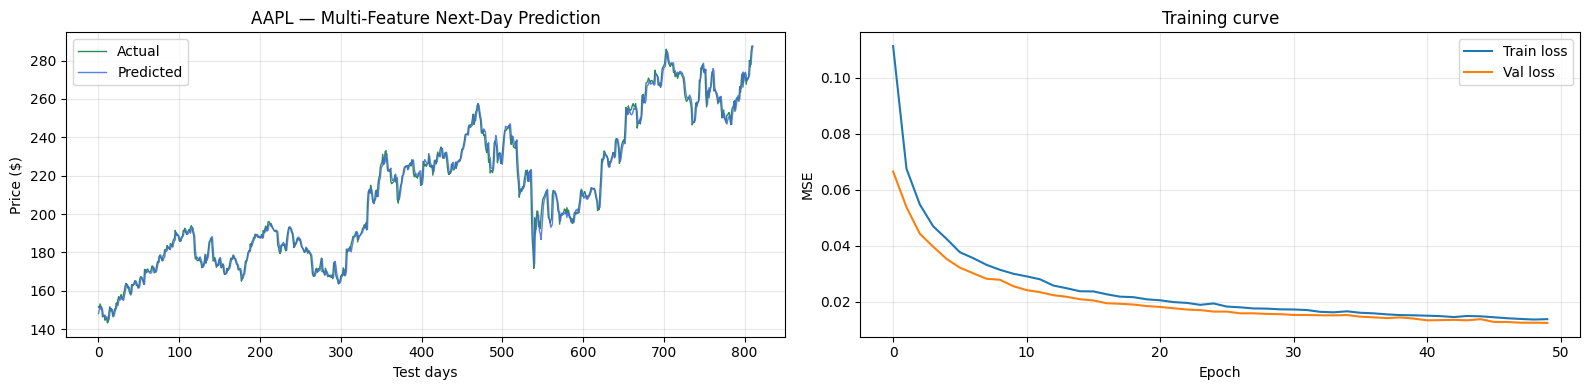


  AMZN  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 8
  RMSE=5.664  MAE=4.237  MAPE=2.32%  R²=0.9826


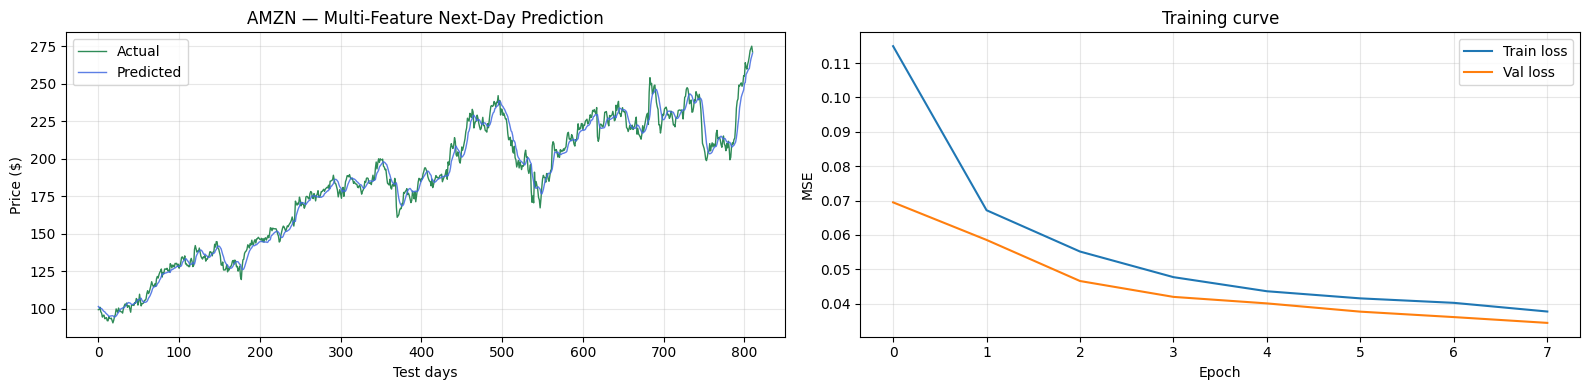


  ASML  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 8
  RMSE=34.457  MAE=25.113  MAPE=2.93%  R²=0.9781


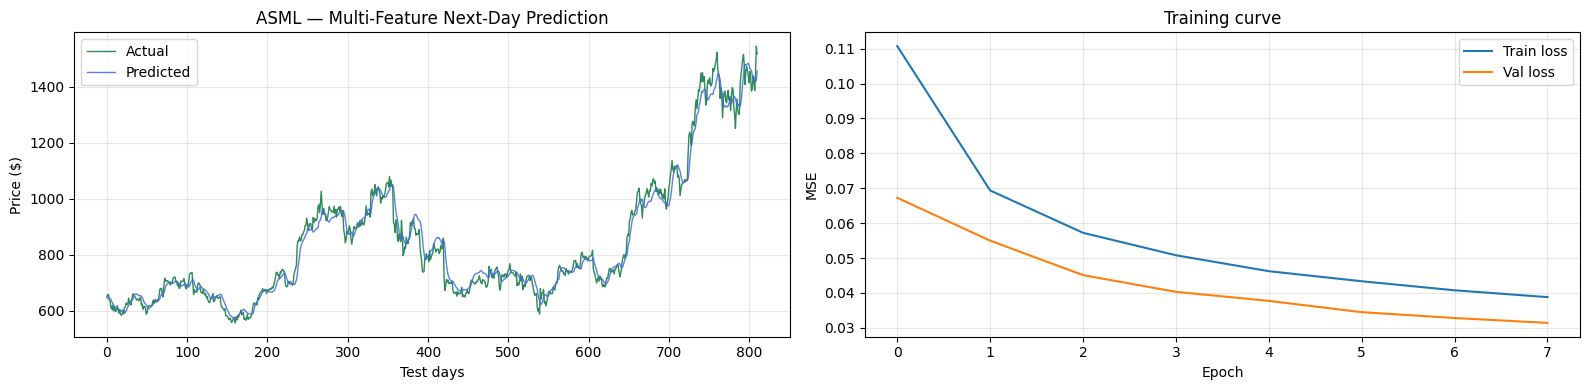


  CSCO  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 8
  RMSE=1.316  MAE=0.927  MAPE=1.60%  R²=0.9886


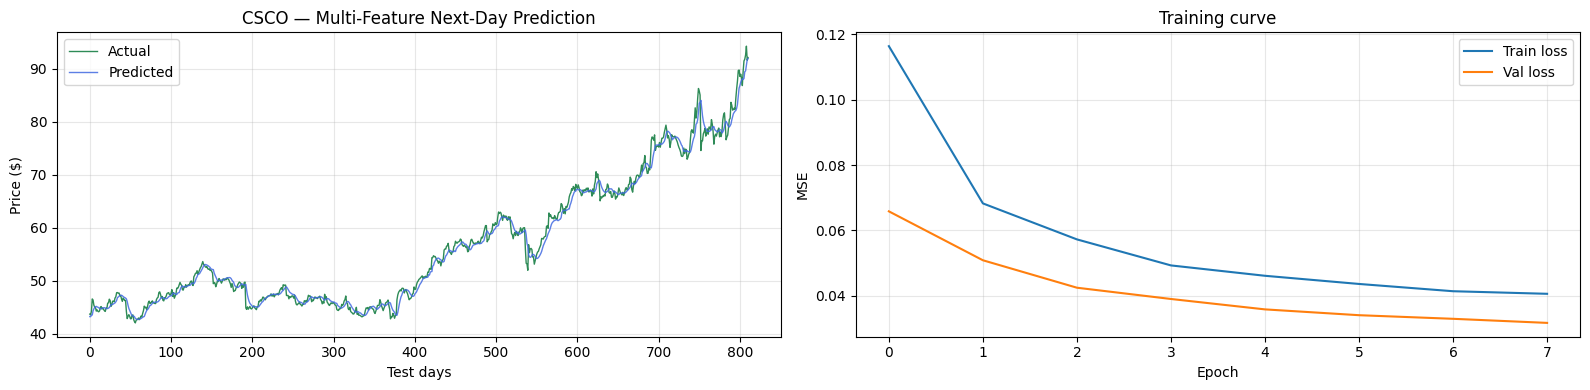


  FANG  (Task 1.1 — multi-feature next-day)
  train=2144  val= 536  test= 670
  Stopped at epoch 8
  RMSE=5.315  MAE=4.052  MAPE=2.57%  R²=0.9353


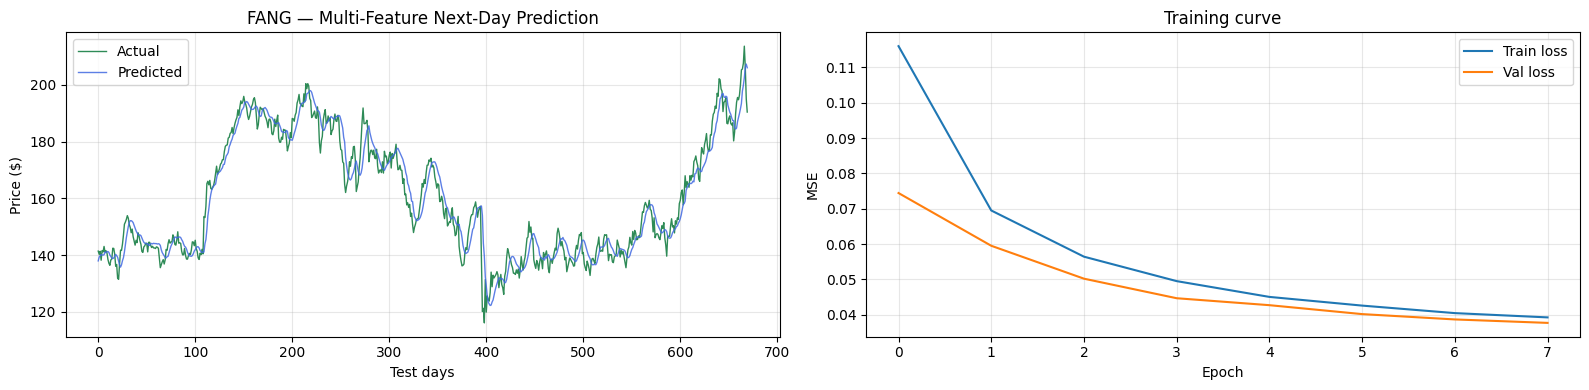


  JPM-PC  (Task 1.1 — multi-feature next-day)
  train=1136  val= 284  test= 355
  Stopped at epoch 8
  RMSE=0.103  MAE=0.080  MAPE=0.33%  R²=0.9705


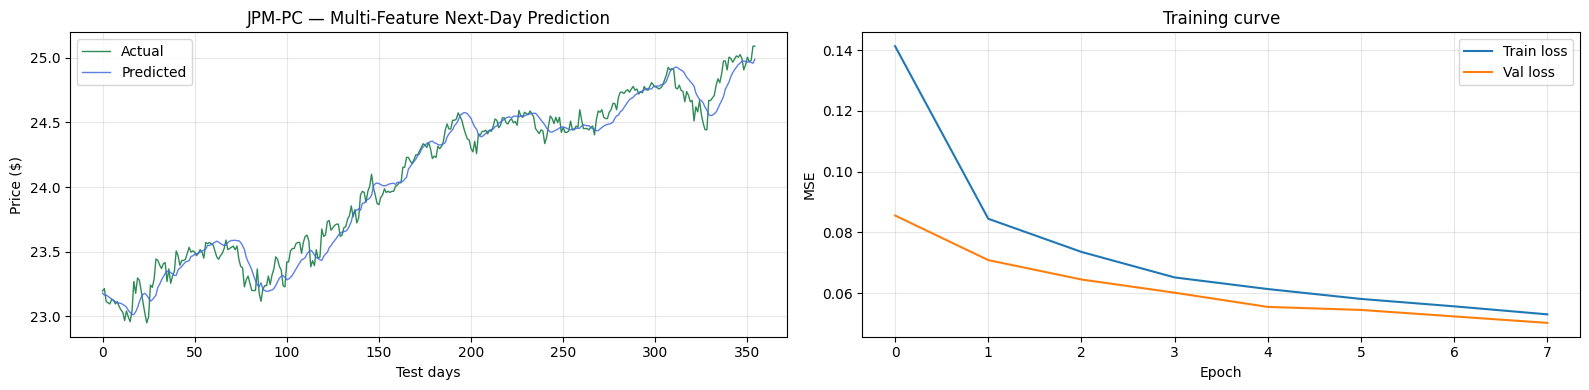


  MSFT  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 8
  RMSE=9.996  MAE=7.621  MAPE=1.94%  R²=0.9778


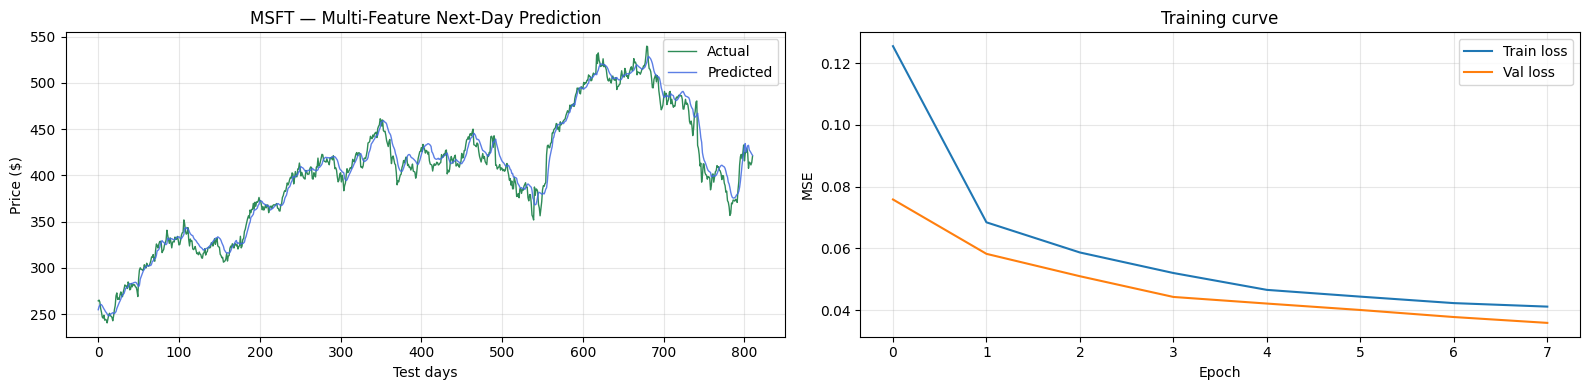


  ORLY  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 8
  RMSE=1.719  MAE=1.315  MAPE=1.66%  R²=0.9864


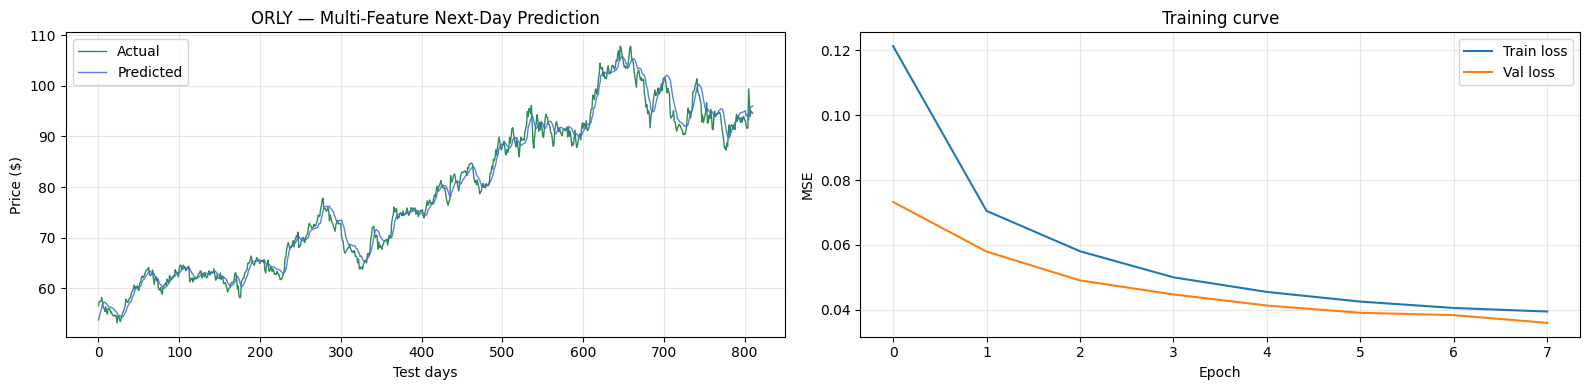


  QCOM  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 8
  RMSE=5.216  MAE=3.811  MAPE=2.63%  R²=0.9588


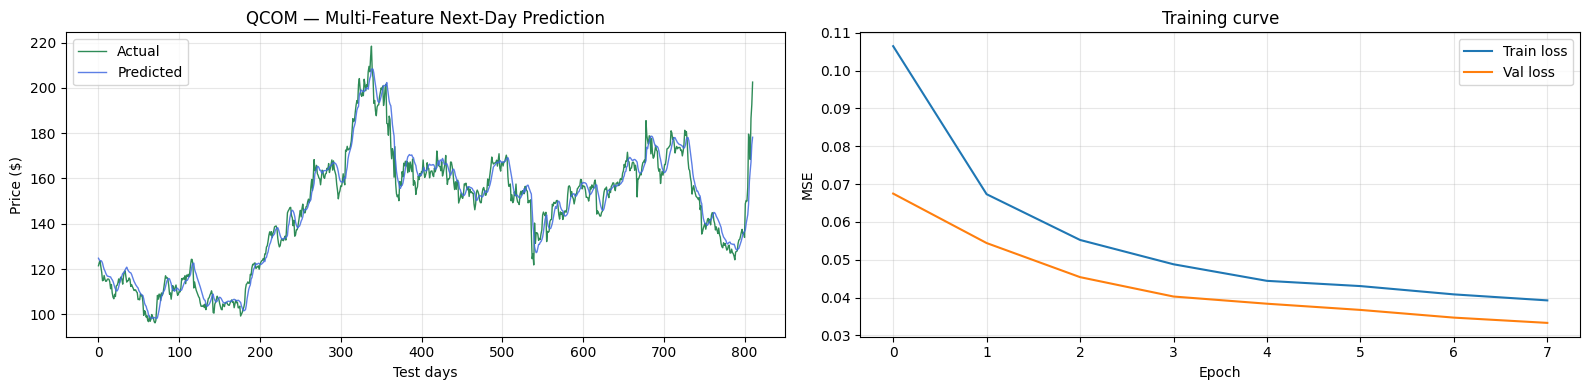


  VLY  (Task 1.1 — multi-feature next-day)
  train=2592  val= 648  test= 811
  Stopped at epoch 8
  RMSE=0.319  MAE=0.246  MAPE=2.84%  R²=0.9698


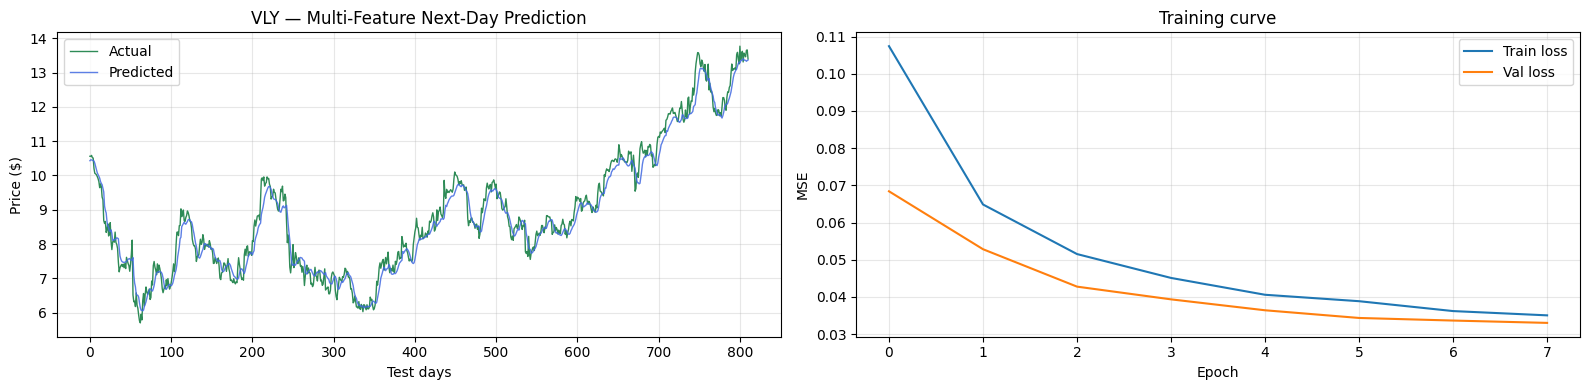

Task 1.1 Summary
           rmse      mae    mape      r2
AAPL     3.5965   2.4893  1.1822  0.9898
AMZN     5.6637   4.2368  2.3170  0.9826
ASML    34.4567  25.1126  2.9313  0.9781
CSCO     1.3157   0.9273  1.5973  0.9886
FANG     5.3153   4.0521  2.5665  0.9353
JPM-PC   0.1028   0.0802  0.3338  0.9705
MSFT     9.9962   7.6209  1.9380  0.9778
ORLY     1.7190   1.3149  1.6611  0.9864
QCOM     5.2158   3.8114  2.6270  0.9588
VLY      0.3195   0.2457  2.8403  0.9698


In [14]:
results_11 = {}   # store metrics for summary table
CLOSE_IDX = FEATURE_COLS.index(TARGET_COL)

for ticker, df in raw_data.items():
    print(f"\n{'='*55}\n  {ticker}  (Task 1.1 — multi-feature next-day)\n{'='*55}")

    # --- Robust column check for FEATURE_COLS specific to this task ---
    missing_cols = [col for col in FEATURE_COLS if col not in df.columns]
    if missing_cols:
        # Attempt to create 'Adj Close' if it's the only missing feature and 'Close' exists
        if 'Adj Close' in missing_cols and 'Close' in df.columns:
            print(f"  {ticker}: 'Adj Close' missing, copying from 'Close'.")
            df['Adj Close'] = df['Close']
            missing_cols = [col for col in FEATURE_COLS if col not in df.columns] # Re-check

        if missing_cols: # If still missing after potential 'Adj Close' fix
            print(f"  {ticker}  SKIPPED for Task 1.1: Missing essential columns {missing_cols}. Actual columns: {df.columns.tolist()}")
            continue

    # ── Windows ─────────────────────────────────────────────
    X, y = make_multi_feature_windows(df, WINDOW_SIZE, FEATURE_COLS, TARGET_COL)

    # ── Split ────────────────────────────────────────────────
    X_train, y_train, X_val, y_val, X_test, y_test = chrono_split(X, y)
    print(f"  train={len(X_train):4d}  val={len(X_val):4d}  test={len(X_test):4d}")

    # ── Scale ────────────────────────────────────────────────
    (X_tr_s, tr_mins, tr_maxs,
     X_va_s, va_mins, va_maxs,
     X_te_s, te_mins, te_maxs) = scale_windows(X_train, X_val, X_test)
    print("  Data scaled.")

    y_tr_s = scale_targets(y_train, tr_mins, tr_maxs, CLOSE_IDX)
    y_va_s = scale_targets(y_val,   va_mins, va_maxs, CLOSE_IDX)
    print("  Targets scaled.")

    # ── Train ────────────────────────────────────────────────
    model = build_model(WINDOW_SIZE, len(FEATURE_COLS))
    print("  Model built. Starting training...")
    history = model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_va_s, y_va_s),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=0
    )
    print(f"  Stopped at epoch {len(history.history['loss'])}")

    # ── Evaluate ─────────────────────────────────────────────
    print("  Starting evaluation...")
    y_pred_s = model.predict(X_te_s, verbose=0).flatten()
    y_pred   = denorm_targets(y_pred_s, te_mins, te_maxs, CLOSE_IDX)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2   = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"  RMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.2f}%  R²={r2:.4f}")
    results_11[ticker] = dict(rmse=rmse, mae=mae, mape=mape, r2=r2)

    # ── Plot ─────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

    ax1.plot(y_test,  label='Actual',    color='seagreen', linewidth=1)
    ax1.plot(y_pred,  label='Predicted', color='royalblue', linewidth=1, alpha=0.85)
    ax1.set_title(f'{ticker} — Multi-Feature Next-Day Prediction')
    ax1.set_xlabel('Test days'); ax1.set_ylabel('Price ($)')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_title('Training curve'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

# Summary table
print("Task 1.1 Summary")
print(pd.DataFrame(results_11).T.round(4).to_string())

## 5. Task 1.2 — k-th Day Forecast (k=7)


  AAPL  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=9.658  MAE=7.253  MAPE=3.42%  R²=0.9262


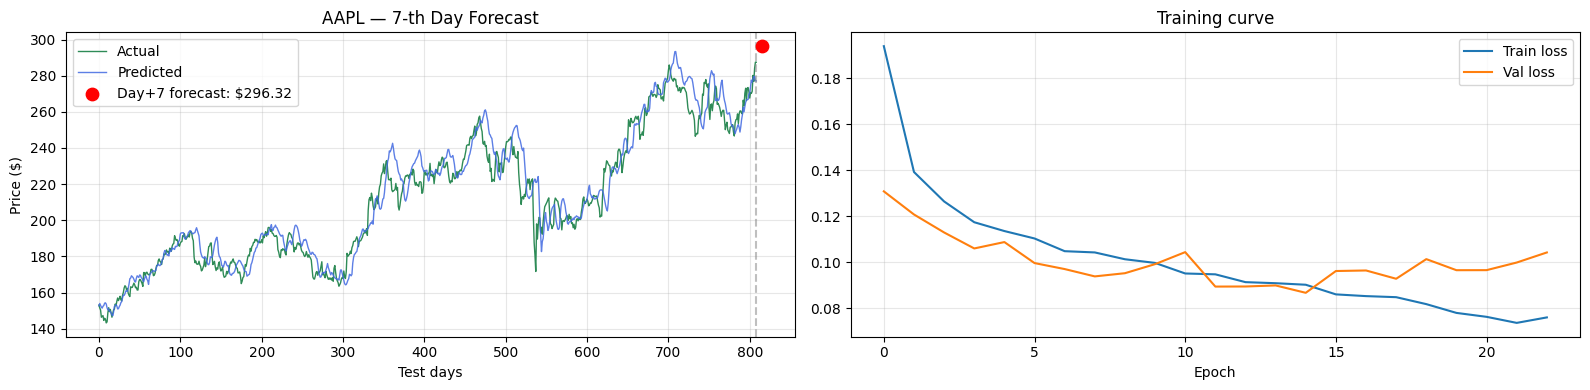

  ► Predicted price on day +7: $296.32

  AMZN  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=10.952  MAE=7.807  MAPE=4.26%  R²=0.9347


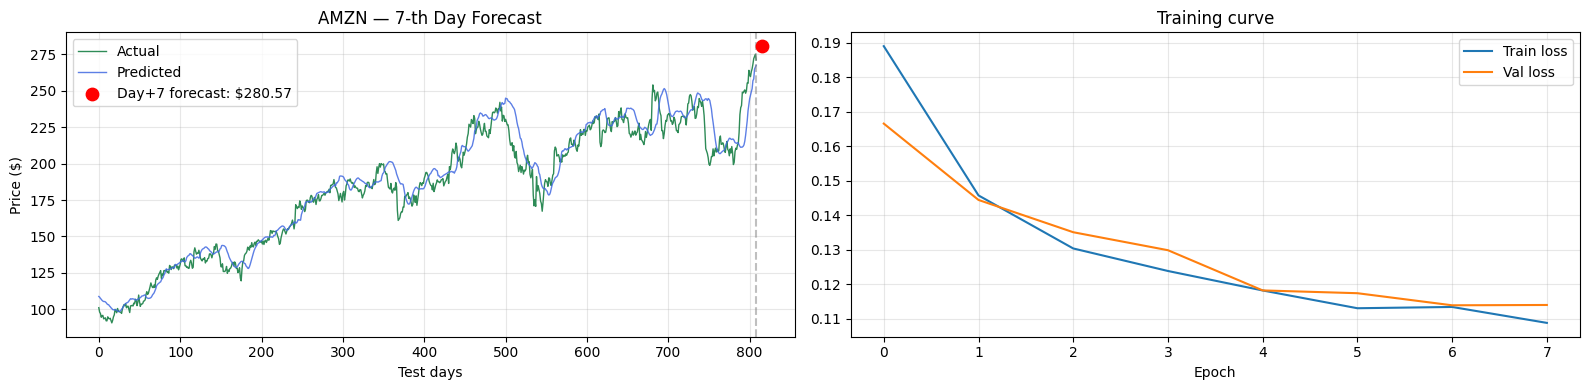

  ► Predicted price on day +7: $280.57

  ASML  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=63.024  MAE=46.401  MAPE=5.52%  R²=0.9269


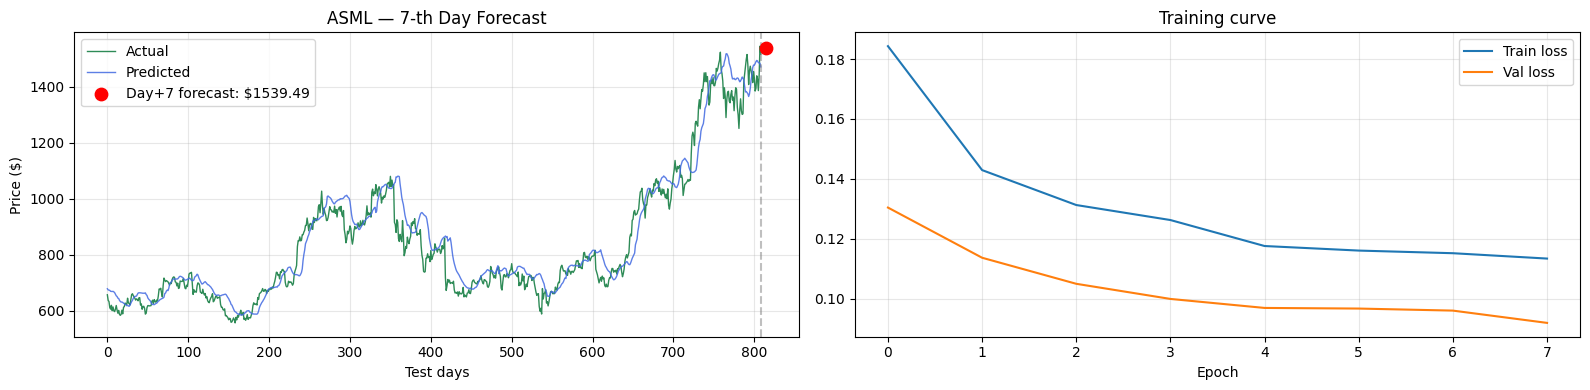

  ► Predicted price on day +7: $1539.49

  CSCO  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=2.177  MAE=1.632  MAPE=2.83%  R²=0.9686


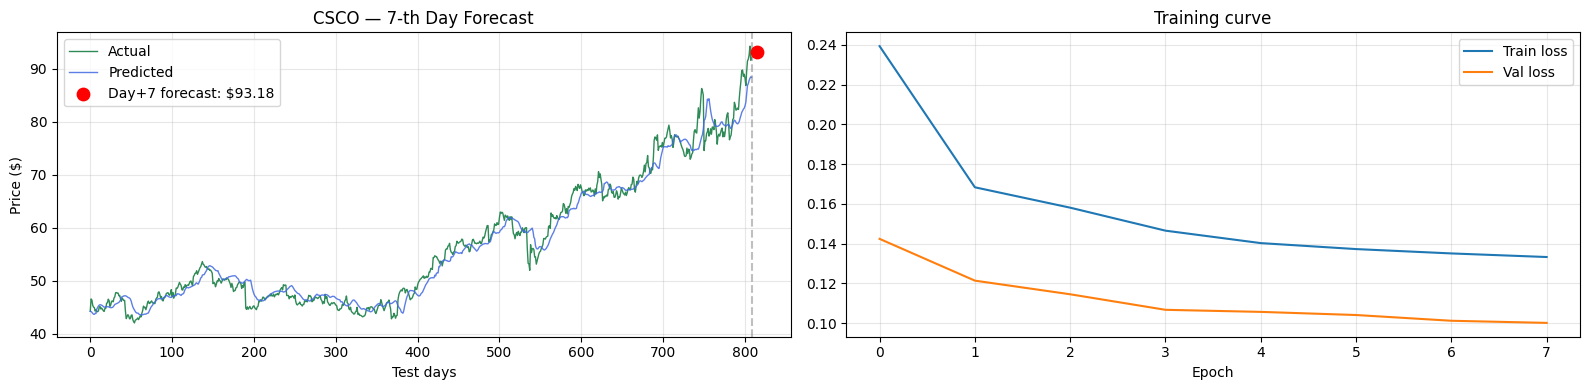

  ► Predicted price on day +7: $93.18

  FANG  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2140, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (535, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (669, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=9.284  MAE=7.410  MAPE=4.68%  R²=0.8026


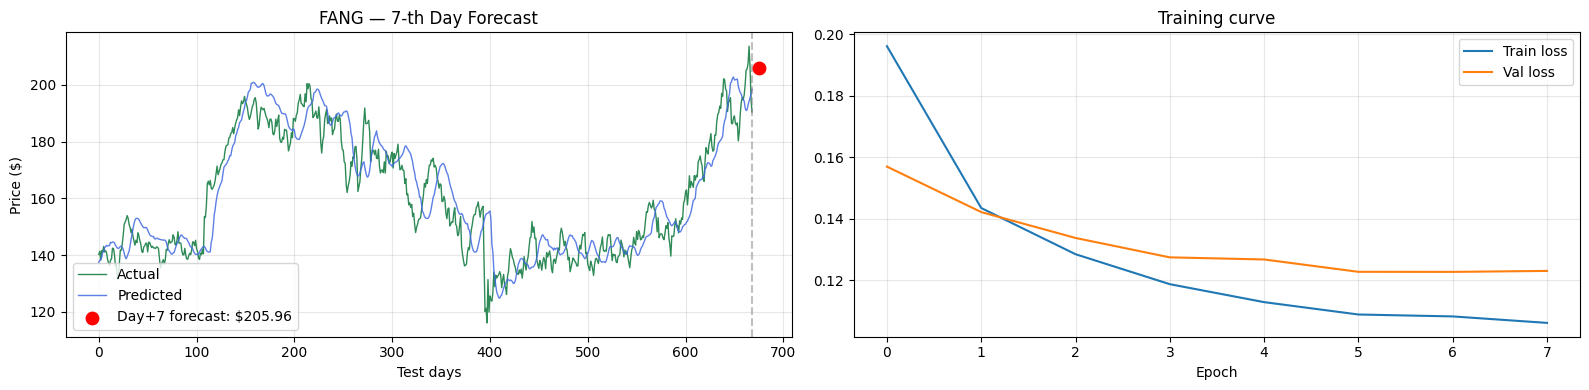

  ► Predicted price on day +7: $205.96

  JPM-PC  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (1132, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (283, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (354, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=0.149  MAE=0.120  MAPE=0.50%  R²=0.9377


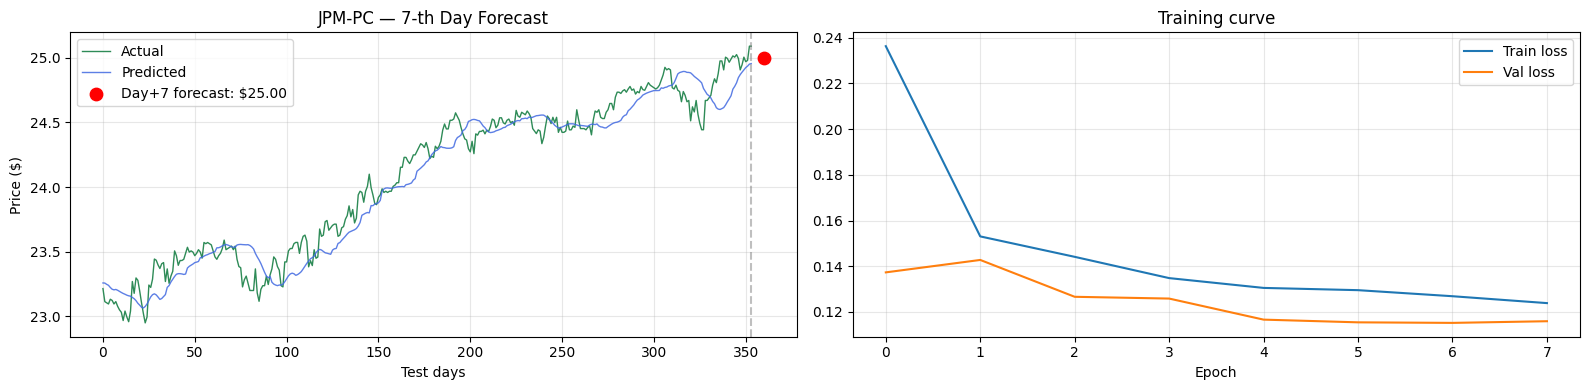

  ► Predicted price on day +7: $25.00

  MSFT  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=17.387  MAE=13.296  MAPE=3.36%  R²=0.9325


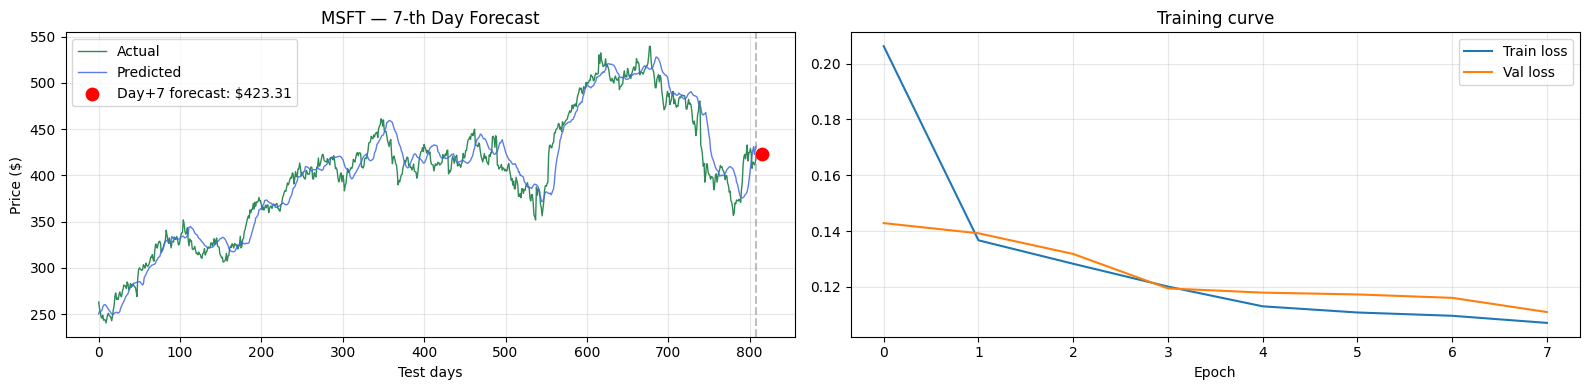

  ► Predicted price on day +7: $423.31

  ORLY  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=2.988  MAE=2.311  MAPE=2.93%  R²=0.9588


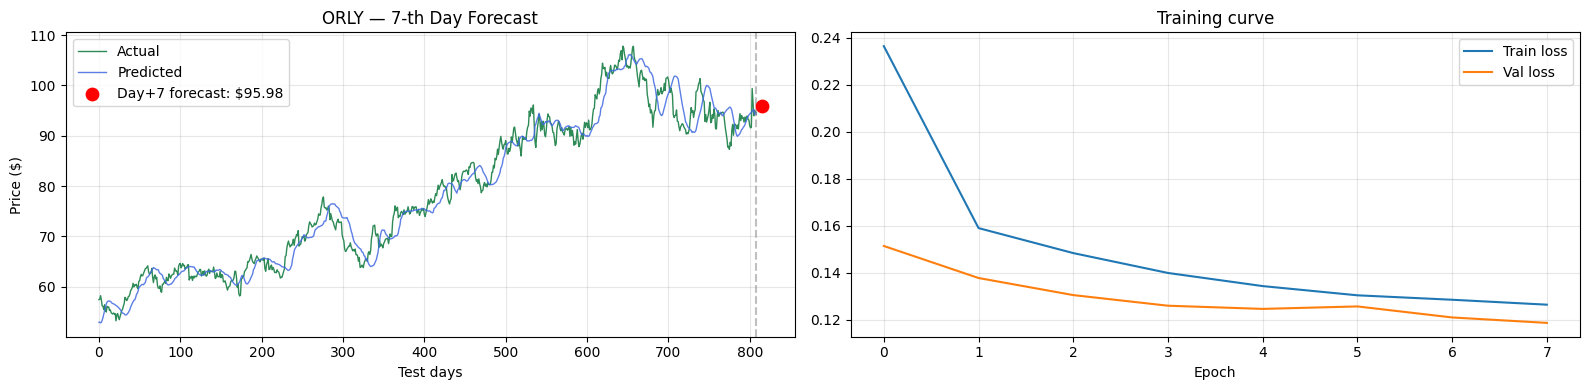

  ► Predicted price on day +7: $95.98

  QCOM  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=9.975  MAE=7.272  MAPE=4.98%  R²=0.8495


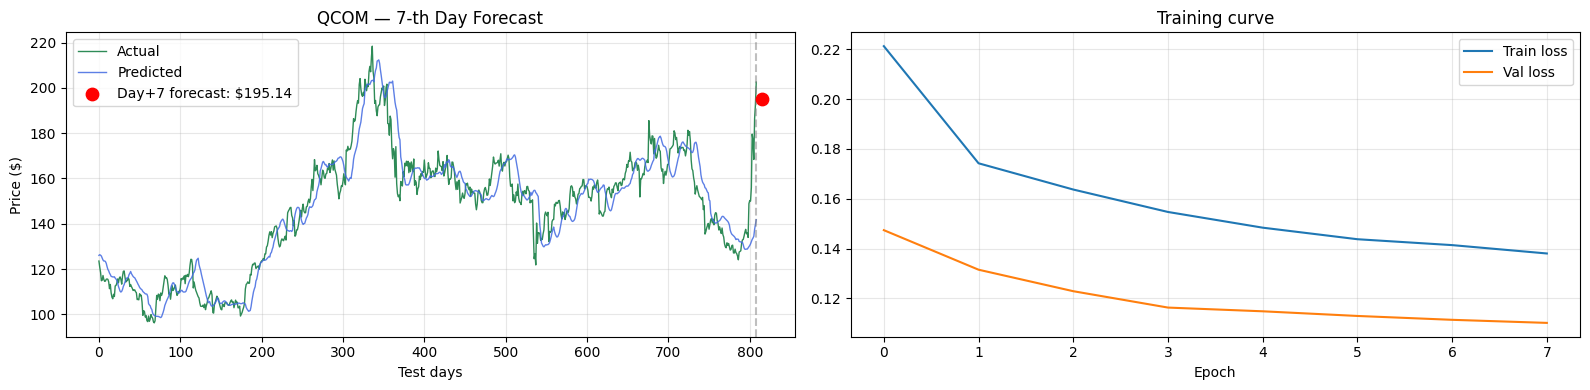

  ► Predicted price on day +7: $195.14

  VLY  (Task 1.2 — 7-th day forecast)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE=0.604  MAE=0.484  MAPE=5.64%  R²=0.8919


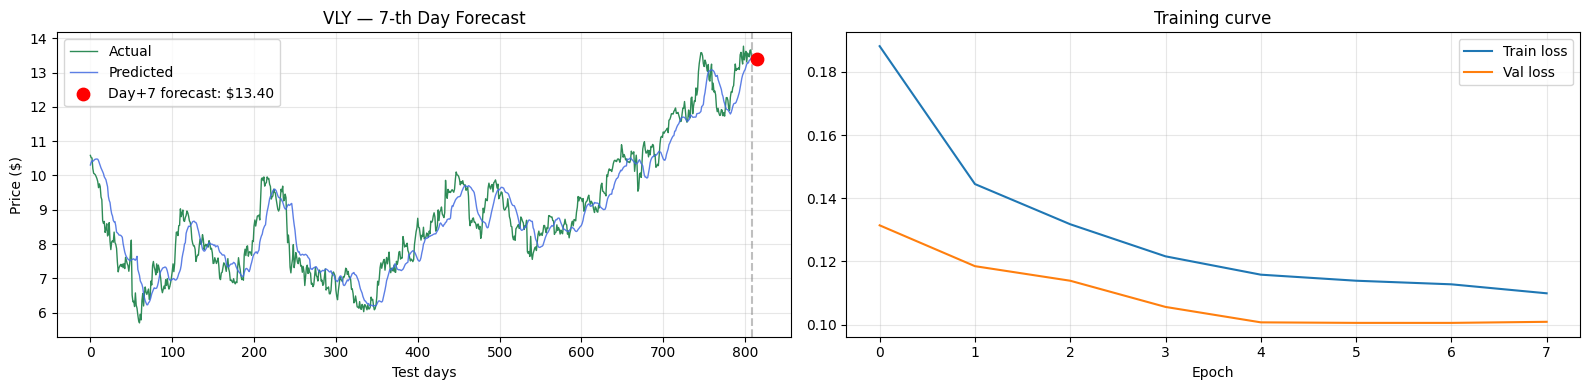

  ► Predicted price on day +7: $13.40
Task 1.2 Summary
           rmse      mae    mape      r2
AAPL     9.6583   7.2527  3.4171  0.9262
AMZN    10.9520   7.8070  4.2579  0.9347
ASML    63.0239  46.4013  5.5196  0.9269
CSCO     2.1772   1.6324  2.8346  0.9686
FANG     9.2843   7.4100  4.6776  0.8026
JPM-PC   0.1490   0.1200  0.4991  0.9377
MSFT    17.3873  13.2959  3.3591  0.9325
ORLY     2.9876   2.3110  2.9327  0.9588
QCOM     9.9746   7.2720  4.9753  0.8495
VLY      0.6043   0.4843  5.6362  0.8919


In [17]:
results_12 = {}

for ticker, df in raw_data.items():
    print(f"\n{'='*55}\n  {ticker}  (Task 1.2 — {K_DAY}-th day forecast)\n{'='*55}")

    X, y = make_kth_day_windows(df, WINDOW_SIZE, FEATURE_COLS, TARGET_COL, K_DAY)
    X_train, y_train, X_val, y_val, X_test, y_test = chrono_split(X, y)

    (X_tr_s, tr_mins, tr_maxs,
     X_va_s, va_mins, va_maxs,
     X_te_s, te_mins, te_maxs) = scale_windows(X_train, X_val, X_test)

    y_tr_s = scale_targets(y_train, tr_mins, tr_maxs, CLOSE_IDX)
    y_va_s = scale_targets(y_val,   va_mins, va_maxs, CLOSE_IDX)

    model = build_model(WINDOW_SIZE, len(FEATURE_COLS))
    history = model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_va_s, y_va_s),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=0
    )

    y_pred_s = model.predict(X_te_s, verbose=0).flatten()
    y_pred   = denorm_targets(y_pred_s, te_mins, te_maxs, CLOSE_IDX)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2   = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"  RMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.2f}%  R²={r2:.4f}")
    results_12[ticker] = dict(rmse=rmse, mae=mae, mape=mape, r2=r2)

    # ── Future forecast point ────────────────────────────────
    last_window = df[FEATURE_COLS].values[-WINDOW_SIZE:].astype(np.float32)
    w_min = last_window.min(axis=0, keepdims=True)
    w_max = last_window.max(axis=0, keepdims=True)
    rng   = np.where(w_max - w_min == 0, 1.0, w_max - w_min)
    last_norm = (last_window - w_min) / rng
    future_pred_s = model.predict(last_norm[np.newaxis], verbose=0)[0, 0]
    future_pred   = future_pred_s * (w_max[0, CLOSE_IDX] - w_min[0, CLOSE_IDX]) + w_min[0, CLOSE_IDX]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].plot(y_test, label='Actual',    color='seagreen', linewidth=1)
    axes[0].plot(y_pred, label='Predicted', color='royalblue', linewidth=1, alpha=0.85)
    axes[0].scatter(len(y_test) + K_DAY - 1, future_pred,
                    color='red', zorder=5, s=80, label=f'Day+{K_DAY} forecast: ${future_pred:.2f}')
    axes[0].axvline(len(y_test) - 1, color='grey', linestyle='--', alpha=0.5)
    axes[0].set_title(f'{ticker} — {K_DAY}-th Day Forecast')
    axes[0].set_xlabel('Test days'); axes[0].set_ylabel('Price ($)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train loss')
    axes[1].plot(history.history['val_loss'], label='Val loss')
    axes[1].set_title('Training curve'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"  ► Predicted price on day +{K_DAY}: ${future_pred:.2f}")

print("Task 1.2 Summary")
print(pd.DataFrame(results_12).T.round(4).to_string())


## 6. Task 1.3 — k Consecutive Days Forecast (k=7)

We use a **multi-output regression head** (`Dense(k)`) that directly predicts the next k closing prices in one forward pass. This avoids compounding errors from autoregressive iterative prediction.


  AAPL  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(4.224), np.float64(5.629), np.float64(6.731), np.float64(7.695), np.float64(8.468), np.float64(9.204), np.float64(9.787)]


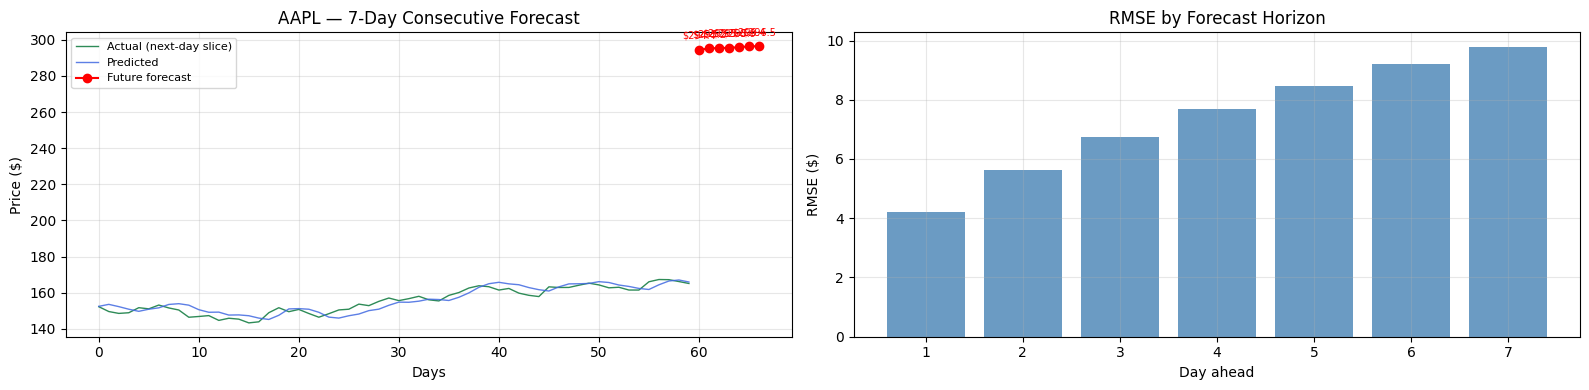

  ► Future 7-day forecast: ['$294.45', '$295.25', '$295.48', '$295.58', '$295.92', '$296.38', '$296.50']

  AMZN  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(6.136), np.float64(7.178), np.float64(8.444), np.float64(9.109), np.float64(9.238), np.float64(10.492), np.float64(10.682)]


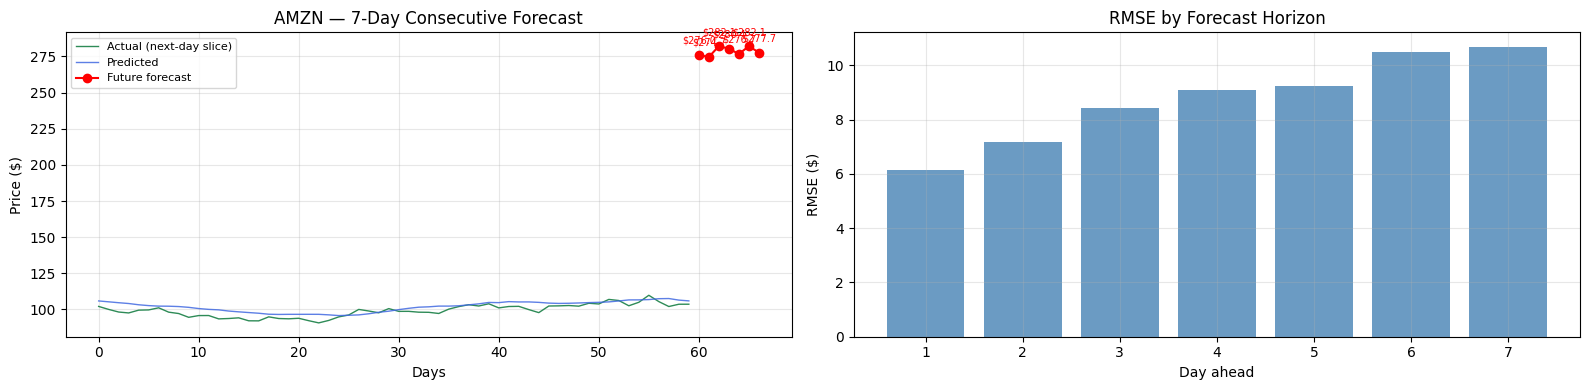

  ► Future 7-day forecast: ['$275.97', '$274.68', '$282.12', '$280.43', '$276.70', '$282.13', '$277.75']

  ASML  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(36.354), np.float64(40.628), np.float64(46.466), np.float64(49.347), np.float64(54.376), np.float64(57.466), np.float64(60.116)]


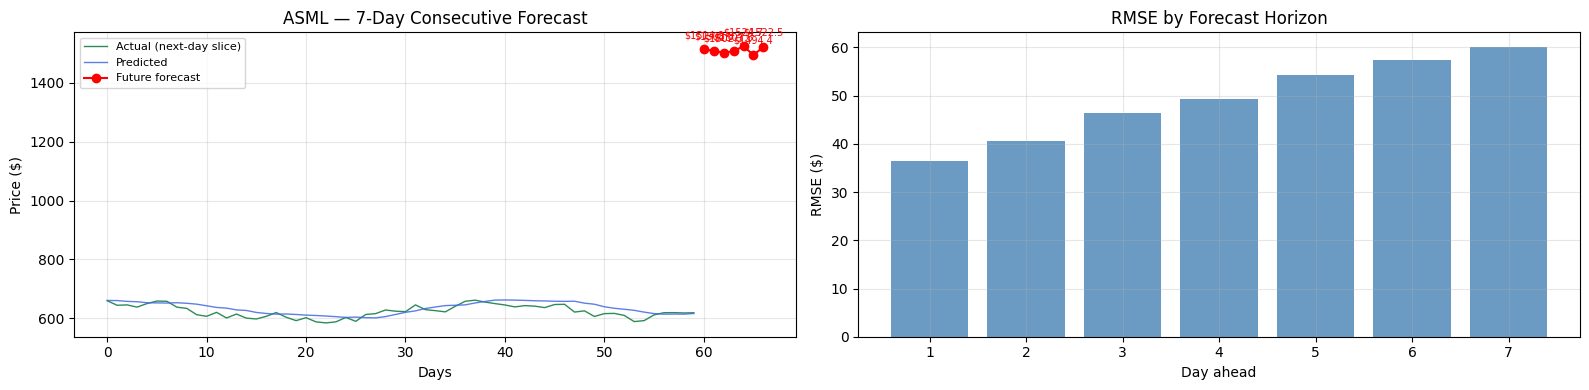

  ► Future 7-day forecast: ['$1513.98', '$1508.79', '$1502.30', '$1507.59', '$1524.68', '$1494.40', '$1522.49']

  CSCO  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(1.37), np.float64(1.496), np.float64(1.712), np.float64(1.839), np.float64(1.936), np.float64(2.092), np.float64(2.134)]


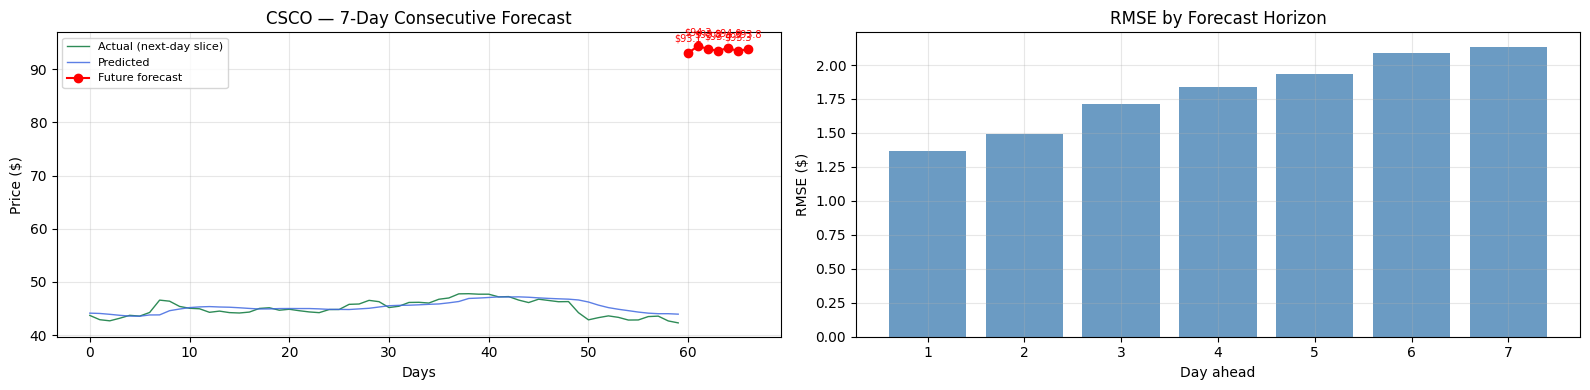

  ► Future 7-day forecast: ['$93.08', '$94.31', '$93.79', '$93.41', '$94.01', '$93.35', '$93.81']

  FANG  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2140, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (535, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (669, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(5.782), np.float64(6.436), np.float64(7.304), np.float64(8.304), np.float64(8.719), np.float64(8.655), np.float64(9.387)]


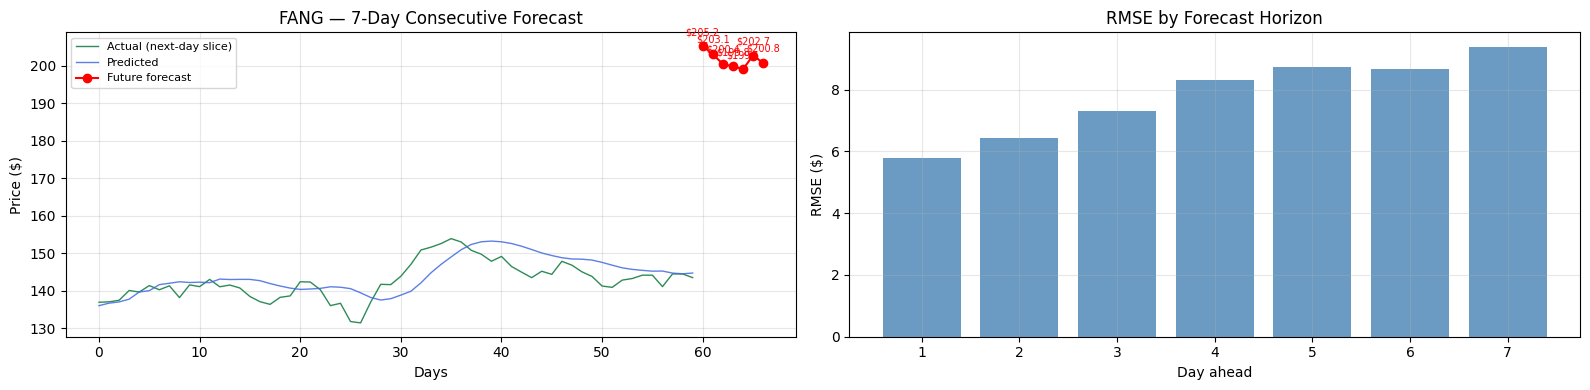

  ► Future 7-day forecast: ['$205.23', '$203.11', '$200.45', '$199.85', '$199.10', '$202.72', '$200.76']

  JPM-PC  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (1132, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (283, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (354, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(0.111), np.float64(0.167), np.float64(0.178), np.float64(0.126), np.float64(0.261), np.float64(0.185), np.float64(0.241)]


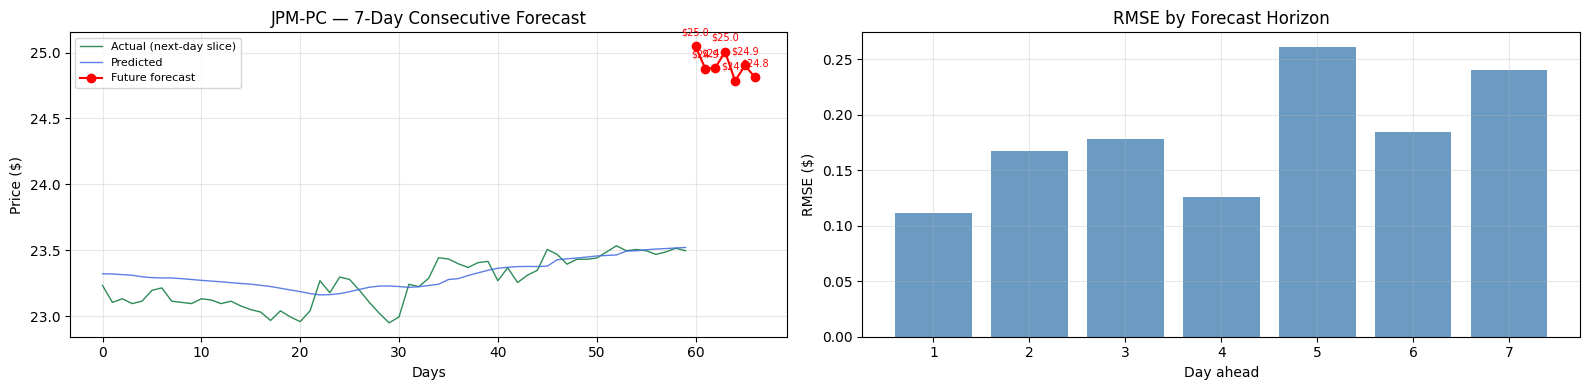

  ► Future 7-day forecast: ['$25.05', '$24.88', '$24.89', '$25.01', '$24.79', '$24.90', '$24.81']

  MSFT  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(13.859), np.float64(12.923), np.float64(15.601), np.float64(14.325), np.float64(17.578), np.float64(18.73), np.float64(19.366)]


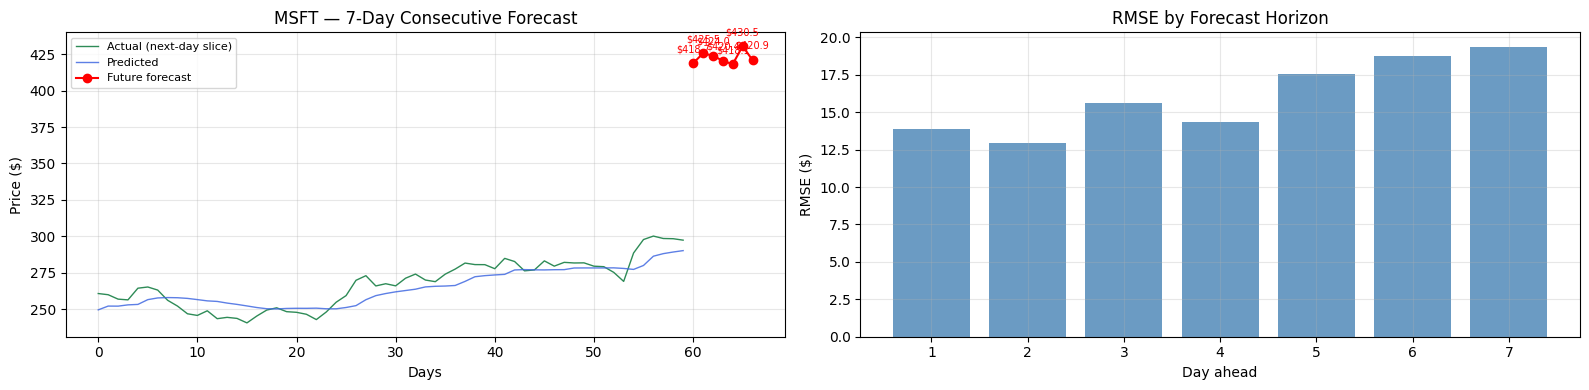

  ► Future 7-day forecast: ['$418.74', '$425.55', '$424.02', '$420.43', '$418.14', '$430.50', '$420.93']

  ORLY  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(1.721), np.float64(2.04), np.float64(2.276), np.float64(2.479), np.float64(2.661), np.float64(2.819), np.float64(2.942)]


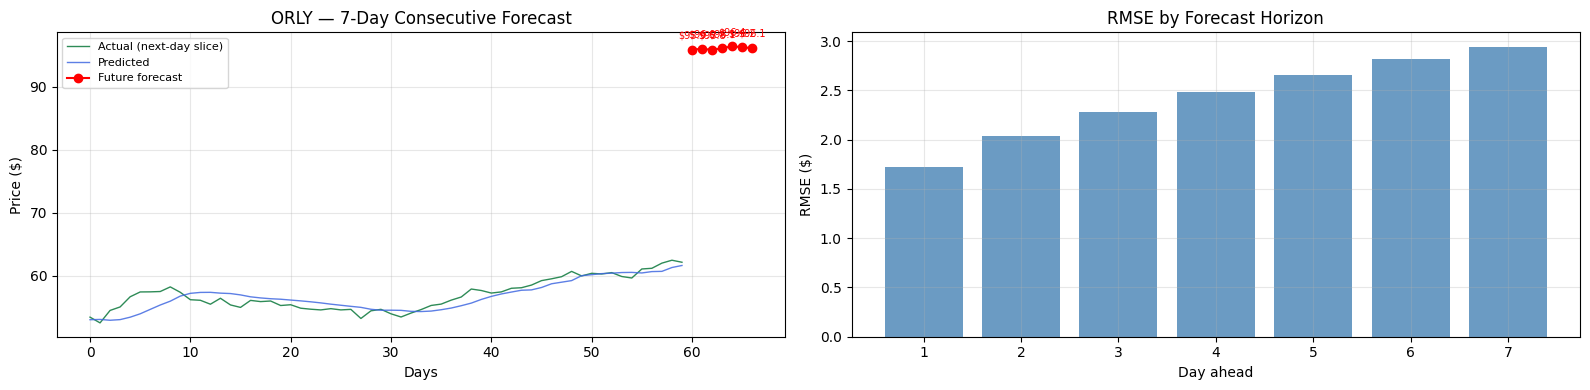

  ► Future 7-day forecast: ['$95.87', '$95.97', '$95.82', '$96.06', '$96.40', '$96.22', '$96.09']

  QCOM  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(5.41), np.float64(6.412), np.float64(7.223), np.float64(7.8), np.float64(8.642), np.float64(9.515), np.float64(9.854)]


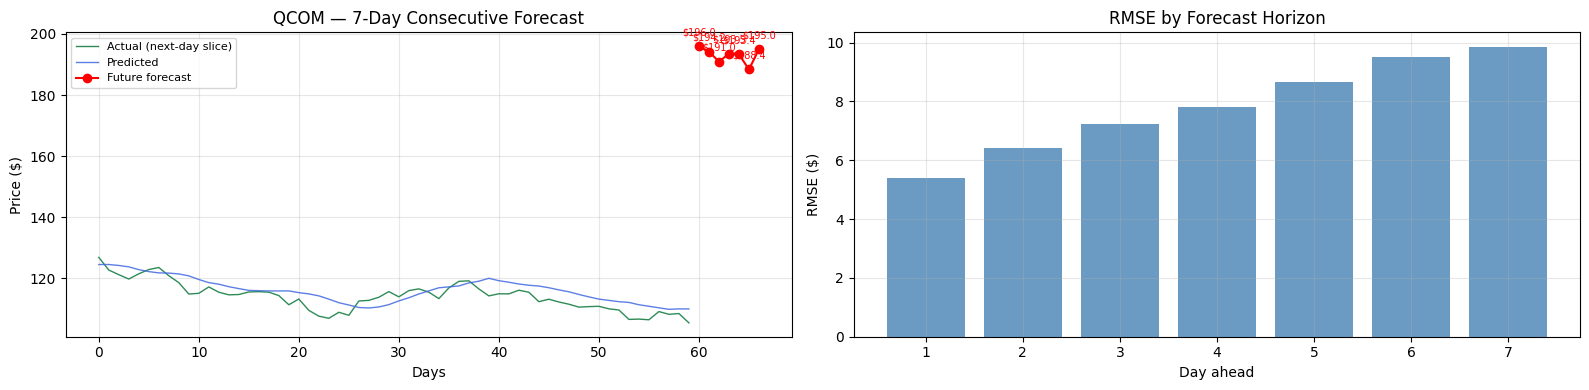

  ► Future 7-day forecast: ['$196.00', '$194.20', '$190.97', '$193.47', '$193.36', '$188.37', '$194.98']

  VLY  (Task 1.3 — 7 consecutive days)
    Scaling train data, shape: (2588, 60, 6)
    train data copied.
    train mins calculated.
    train maxs calculated.
    train range calculated.
    train data scaled.
    Scaling val data, shape: (648, 60, 6)
    val data copied.
    val mins calculated.
    val maxs calculated.
    val range calculated.
    val data scaled.
    Scaling test data, shape: (809, 60, 6)
    test data copied.
    test mins calculated.
    test maxs calculated.
    test range calculated.
    test data scaled.
  RMSE per horizon: [np.float64(0.332), np.float64(0.413), np.float64(0.437), np.float64(0.488), np.float64(0.53), np.float64(0.566), np.float64(0.631)]


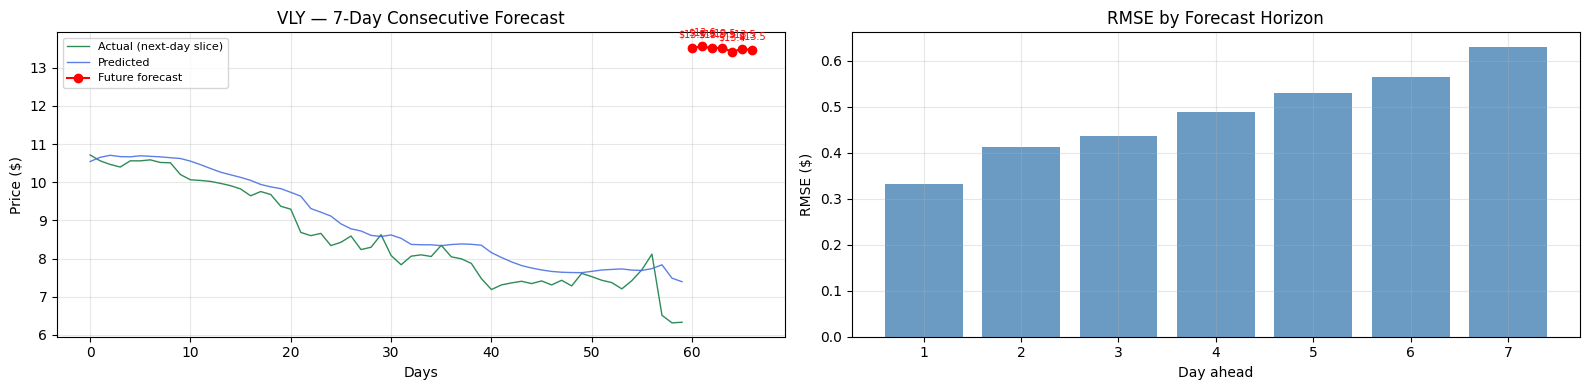

  ► Future 7-day forecast: ['$13.51', '$13.56', '$13.50', '$13.53', '$13.41', '$13.50', '$13.45']

── Task 1.3 RMSE Summary (all tickers) ─────────────
        rmse_d1  rmse_d2  rmse_d3  rmse_d4  rmse_d5  rmse_d6  rmse_d7
AAPL     4.2243   5.6289   6.7311   7.6952   8.4678   9.2037   9.7867
AMZN     6.1362   7.1778   8.4445   9.1088   9.2378  10.4921  10.6817
ASML    36.3540  40.6277  46.4664  49.3469  54.3756  57.4656  60.1165
CSCO     1.3702   1.4958   1.7122   1.8385   1.9355   2.0921   2.1340
FANG     5.7821   6.4360   7.3038   8.3036   8.7195   8.6549   9.3872
JPM-PC   0.1113   0.1672   0.1779   0.1256   0.2613   0.1846   0.2407
MSFT    13.8591  12.9231  15.6010  14.3248  17.5783  18.7301  19.3664
ORLY     1.7213   2.0396   2.2763   2.4786   2.6611   2.8190   2.9420
QCOM     5.4101   6.4121   7.2230   7.7996   8.6419   9.5149   9.8543
VLY      0.3320   0.4125   0.4372   0.4884   0.5304   0.5656   0.6305


In [18]:
results_13 = {}

for ticker, df in raw_data.items():
    print(f"\n{'='*55}\n  {ticker}  (Task 1.3 — {K_CONSEC} consecutive days)\n{'='*55}")

    X, y = make_multi_output_windows(df, WINDOW_SIZE, FEATURE_COLS, TARGET_COL, K_CONSEC)
    X_train, y_train, X_val, y_val, X_test, y_test = chrono_split(X, y)

    (X_tr_s, tr_mins, tr_maxs,
     X_va_s, va_mins, va_maxs,
     X_te_s, te_mins, te_maxs) = scale_windows(X_train, X_val, X_test)

    # Scale multi-output targets (each row scaled by its window's Close min/max)
    def scale_multi(y, X_mins, X_maxs, cidx):
        mins = X_mins[:, 0, cidx, np.newaxis]
        maxs = X_maxs[:, 0, cidx, np.newaxis]
        rng  = np.where(maxs - mins == 0, 1.0, maxs - mins)
        return (y - mins) / rng

    y_tr_s = scale_multi(y_train, tr_mins, tr_maxs, CLOSE_IDX)
    y_va_s = scale_multi(y_val,   va_mins, va_maxs, CLOSE_IDX)

    model = build_model(WINDOW_SIZE, len(FEATURE_COLS), n_output=K_CONSEC)
    history = model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_va_s, y_va_s),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=0
    )

    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = denorm_targets(y_pred_s, te_mins, te_maxs, CLOSE_IDX)

    # Evaluate on every horizon
    rmse_per_day = [np.sqrt(mean_squared_error(y_test[:, d], y_pred[:, d]))
                    for d in range(K_CONSEC)]
    mae_per_day  = [mean_absolute_error(y_test[:, d], y_pred[:, d])
                    for d in range(K_CONSEC)]
    print(f"  RMSE per horizon: {[round(r,3) for r in rmse_per_day]}")
    results_13[ticker] = dict(zip([f'rmse_d{d+1}' for d in range(K_CONSEC)], rmse_per_day))

    # ── Future k-day forecast ────────────────────────────────
    last_window = df[FEATURE_COLS].values[-WINDOW_SIZE:].astype(np.float32)
    w_min = last_window.min(axis=0, keepdims=True)
    w_max = last_window.max(axis=0, keepdims=True)
    rng   = np.where(w_max - w_min == 0, 1.0, w_max - w_min)
    last_norm = (last_window - w_min) / rng
    future_s  = model.predict(last_norm[np.newaxis], verbose=0)[0]
    future     = future_s * (w_max[0, CLOSE_IDX] - w_min[0, CLOSE_IDX]) + w_min[0, CLOSE_IDX]

    # ── Plot one example test sequence ───────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Show last 60 test actuals + the first forecast sequence
    sample_actual = y_test[:60, 0]
    sample_pred   = y_pred[:60, 0]
    axes[0].plot(sample_actual, label='Actual (next-day slice)', color='seagreen', linewidth=1)
    axes[0].plot(sample_pred,   label='Predicted',              color='royalblue', linewidth=1, alpha=0.85)

    # Overlay future forecast
    x_future = np.arange(60, 60 + K_CONSEC)
    axes[0].plot(x_future, future, 'ro-', markersize=6, label='Future forecast')
    for d, p in zip(x_future, future):
        axes[0].annotate(f'${p:.1f}', (d, p), textcoords='offset points',
                         xytext=(0, 8), ha='center', fontsize=7, color='red')
    axes[0].set_title(f'{ticker} — {K_CONSEC}-Day Consecutive Forecast')
    axes[0].set_xlabel('Days'); axes[0].set_ylabel('Price ($)')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].bar(range(1, K_CONSEC+1), rmse_per_day, color='steelblue', alpha=0.8)
    axes[1].set_title('RMSE by Forecast Horizon')
    axes[1].set_xlabel('Day ahead'); axes[1].set_ylabel('RMSE ($)')
    axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"  ► Future {K_CONSEC}-day forecast: {[f'${p:.2f}' for p in future]}")

print("\n── Task 1.3 RMSE Summary (all tickers) ─────────────")
print(pd.DataFrame(results_13).T.round(4).to_string())


## 7. Final Metrics Summary

In [19]:
summary = pd.DataFrame({
    'Task 1.1 RMSE': {t: results_11[t]['rmse'] for t in results_11},
    'Task 1.1 MAPE%': {t: results_11[t]['mape'] for t in results_11},
    'Task 1.1 R²':   {t: results_11[t]['r2']   for t in results_11},
    'Task 1.2 RMSE': {t: results_12[t]['rmse'] for t in results_12},
    'Task 1.2 MAPE%': {t: results_12[t]['mape'] for t in results_12},
}).round(4)

print(summary.to_string())
print("\nNote: MAPE (Mean Absolute Percentage Error) is the primary metric.")
print("Task 1.3 RMSE increases with forecast horizon — expected behaviour.")


        Task 1.1 RMSE  Task 1.1 MAPE%  Task 1.1 R²  Task 1.2 RMSE  Task 1.2 MAPE%
AAPL           3.5965          1.1822       0.9898         9.6583          3.4171
AMZN           5.6637          2.3170       0.9826        10.9520          4.2579
ASML          34.4567          2.9313       0.9781        63.0239          5.5196
CSCO           1.3157          1.5973       0.9886         2.1772          2.8346
FANG           5.3153          2.5665       0.9353         9.2843          4.6776
JPM-PC         0.1028          0.3338       0.9705         0.1490          0.4991
MSFT           9.9962          1.9380       0.9778        17.3873          3.3591
ORLY           1.7190          1.6611       0.9864         2.9876          2.9327
QCOM           5.2158          2.6270       0.9588         9.9746          4.9753
VLY            0.3195          2.8403       0.9698         0.6043          5.6362

Note: MAPE (Mean Absolute Percentage Error) is the primary metric.
Task 1.3 RMSE increases with f

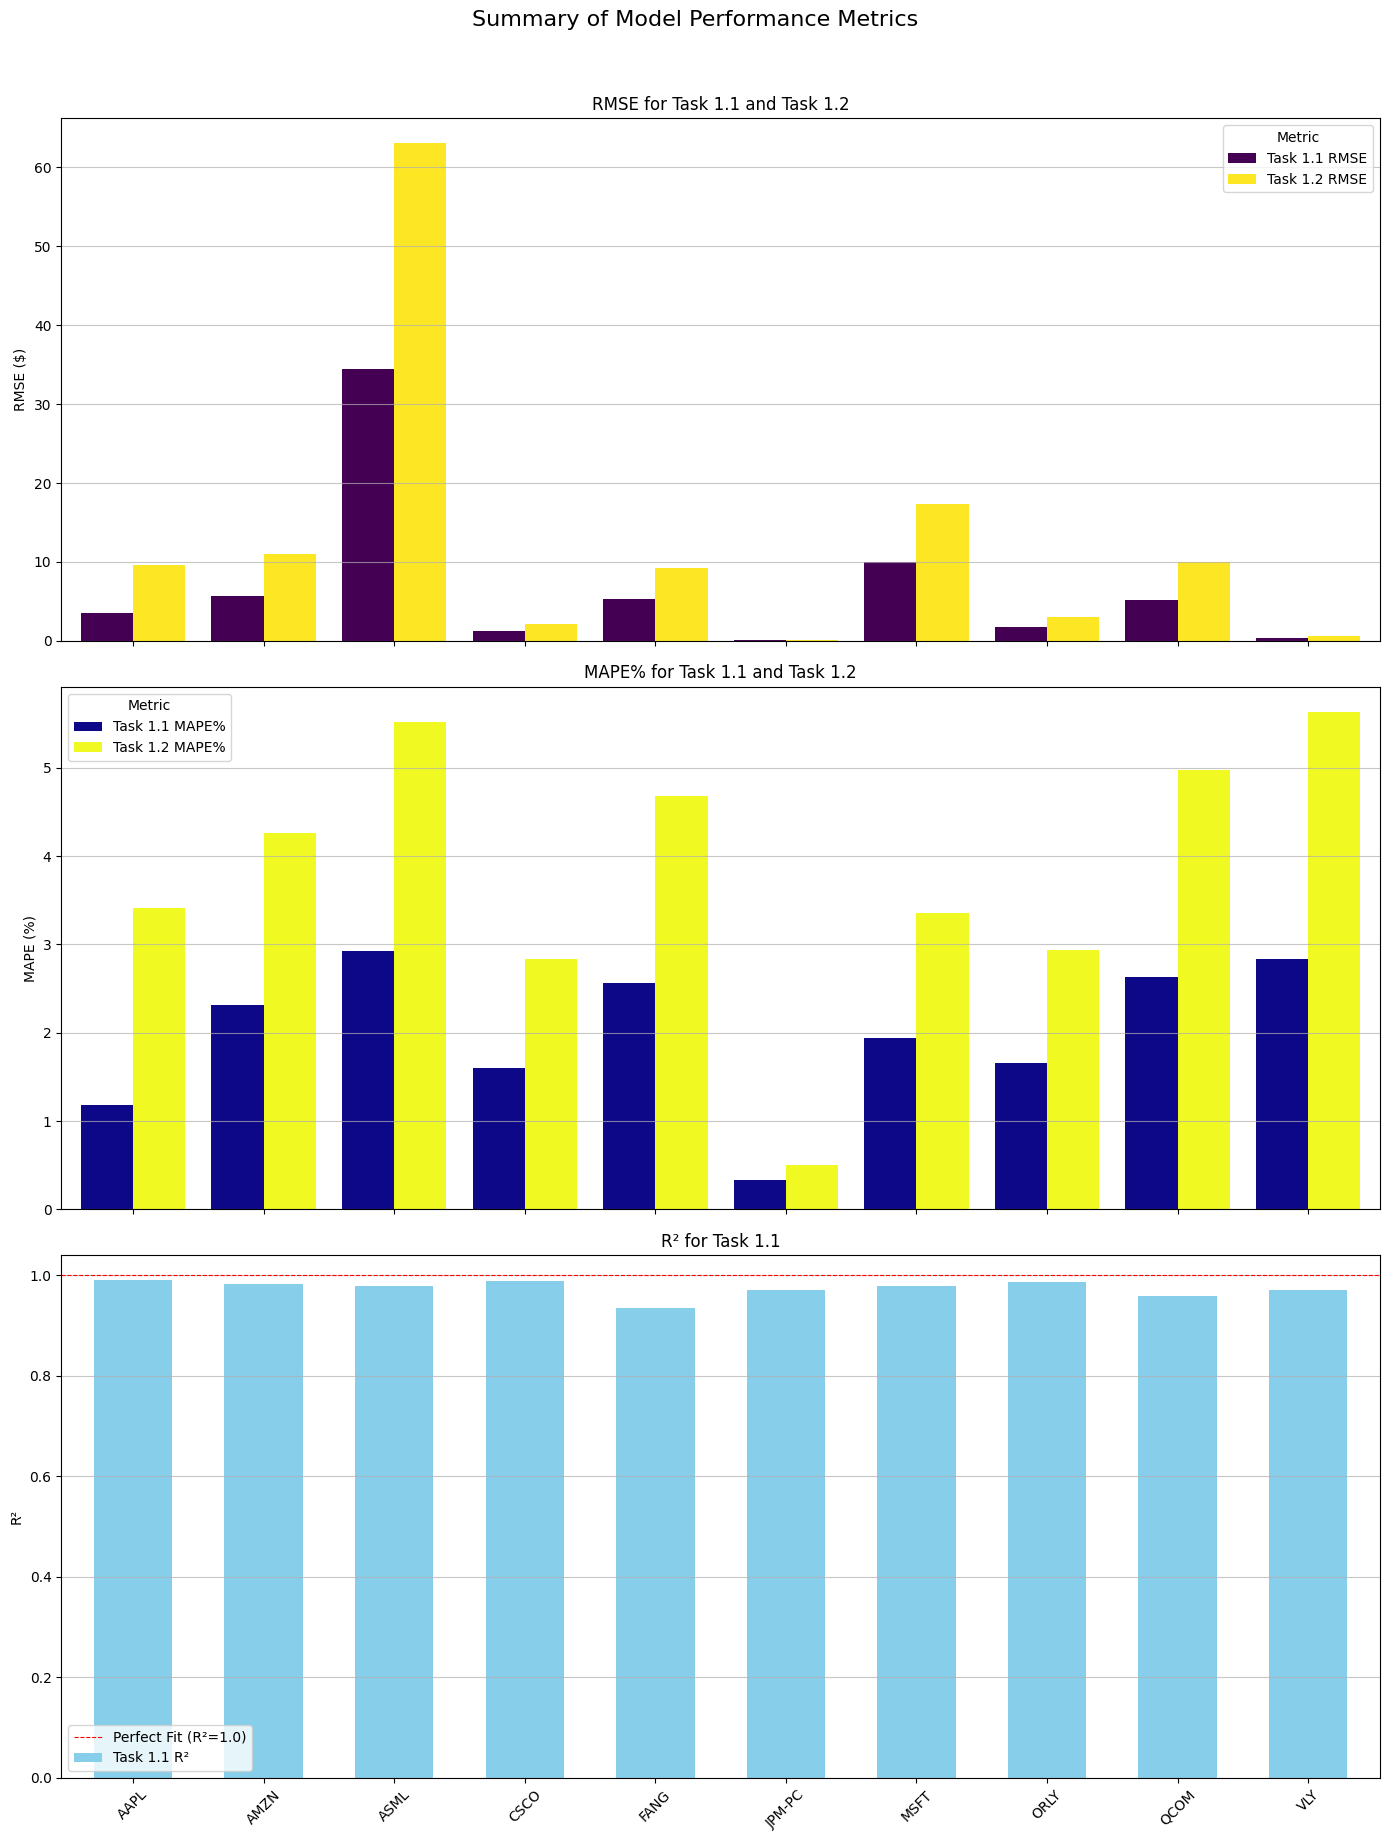

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for RMSE, MAPE%, and R²
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)
fig.suptitle('Summary of Model Performance Metrics', fontsize=16, y=1.02)

# Plot RMSE
summary[['Task 1.1 RMSE', 'Task 1.2 RMSE']].plot(kind='bar', ax=axes[0], colormap='viridis', width=0.8)
axes[0].set_title('RMSE for Task 1.1 and Task 1.2')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.7)
axes[0].legend(title='Metric')

# Plot MAPE%
summary[['Task 1.1 MAPE%', 'Task 1.2 MAPE%']].plot(kind='bar', ax=axes[1], colormap='plasma', width=0.8)
axes[1].set_title('MAPE% for Task 1.1 and Task 1.2')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.7)
axes[1].legend(title='Metric')

# Plot R² (only Task 1.1 in summary)
summary['Task 1.1 R²'].plot(kind='bar', ax=axes[2], color='skyblue', width=0.6)
axes[2].set_title('R² for Task 1.1')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.7)
axes[2].axhline(y=1.0, color='r', linestyle='--', linewidth=0.8, label='Perfect Fit (R²=1.0)')
axes[2].legend()

plt.tight_layout()
plt.show()